# Introdução

## Contexto

Este é um conjunto de dados público brasileiro de comércio eletrónico relativo a encomendas efetuadas na Olist Store. O conjunto de dados contém informações sobre 100 mil encomendas, de 2016 a 2018, efetuadas em várias plataformas de comércio eletrónico no Brasil. As suas características permitem analisar uma encomenda sob várias perspetivas: desde o estado da encomenda, preço, pagamento e desempenho do envio até à localização do cliente, atributos do produto e, por fim, comentários escritos pelos clientes.

Este conjunto de dados foi gentilmente cedido pela Olist, a maior loja de departamentos dos mercados online brasileiros. A Olist conecta pequenas empresas de todo o Brasil a canais de venda de forma simples e com um único contrato. Esses comerciantes podem vender os seus produtos através da Loja Olist e enviá-los diretamente aos clientes através dos parceiros de logística da Olist.

Depois de um cliente adquirir o produto na Olist Store, o vendedor é notificado para processar a encomenda. Assim que o cliente receber o produto, ou quando a data de entrega prevista chegar, o cliente recebe um questionário de satisfação por e-mail, onde pode avaliar a experiência de compra e deixar alguns comentários.

## Dados

O dataset é composto por 9 tabelas relacionadas entre si através de chaves como `order_id`, `customer_id`, `seller_id` e `product_id`:

| Ficheiro | Descrição |
|---|---|
| `olist_orders_dataset.csv` | Tabela central — estado da encomenda, timestamps de compra, aprovação, envio e entrega |
| `olist_order_items_dataset.csv` | Itens por encomenda — produto, vendedor, preço e frete |
| `olist_order_payments_dataset.csv` | Pagamentos — método, parcelas e valor |
| `olist_order_reviews_dataset.csv` | Avaliações — nota (1–5) e comentários do cliente |
| `olist_customers_dataset.csv` | Cliente — cidade, estado e CEP |
| `olist_sellers_dataset.csv` | Vendedor — cidade e estado |
| `olist_products_dataset.csv` | Produto — categoria, dimensões e peso |
| `olist_geolocation_dataset.csv` | Coordenadas geográficas por CEP |
| `product_category_name_translation.csv` | Tradução das categorias PT → EN |

## Objetivo

Este projecto analisa o impacto dos atrasos nas encomendas sobre a experiência do cliente, respondendo a quatro questões:

1. **Assimetria do atraso** — Quais categorias e faixas de valor concentram os maiores atrasos? O atraso distribui-se de forma uniforme ou há padrões específicos?
2. **Ponto de ruptura** — A partir de quantos dias de atraso a avaliação do cliente colapsa? A relação é linear ou existe um limiar crítico?
3. **Logística vs. promessa regional** — Os atrasos resultam de logística lenta ou de janelas de entrega irrealistas? A resposta varia por estado?
4. **Variância por vendedor** — Dentro do mesmo corredor logístico, o tempo de despacho do vendedor é uma variável oculta que explica diferenças de desempenho?

A variável central de análise é `delta_dias`, definida como a diferença entre a data de entrega real e a data de entrega estimada. Valores positivos indicam atraso; valores negativos indicam entrega antecipada.

## Esquema de Dados

![Schema do Dataset Olist](assets/schema.png)

# Setup e Dados

## Ambiente

### Importação bibliotecas

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb

### Configurações Globais

In [2]:
# Reprodutibilidade — seed único
RANDOM_STATE = 42

# Exibição de dados
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

### Carregamento de dados

In [3]:
customers_raw = pd.read_csv('../data/raw/olist_customers_dataset.csv')

In [4]:
geolocations_raw = pd.read_csv('../data/raw/olist_geolocation_dataset.csv')

In [5]:
items_raw = pd.read_csv('../data/raw/olist_order_items_dataset.csv')

In [6]:
payments_raw = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')

In [7]:
reviews_raw = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')

In [8]:
orders_raw = pd.read_csv('../data/raw/olist_orders_dataset.csv')      

In [9]:
products_raw = pd.read_csv('../data/raw/olist_products_dataset.csv')

In [10]:
sellers_raw = pd.read_csv('../data/raw/olist_sellers_dataset.csv')

In [11]:
categorys_raw = pd.read_csv('../data/raw/product_category_name_translation.csv')

## Pré Processamento

### Primeiras impressões

#### Customers

In [12]:
# primeira visualização
print(customers_raw.head())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  


In [13]:
# descoberta informações sobre os dados  
print(customers_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None


Não foram detectados valores nulos no dataframe. 

`customer_zip_code_prefix` que, por ser um identificador geográfico e não um valor numérico, pode ser convertido para `str` por consistência.

#### Geolocation

In [14]:
# primeira visualização
print(geolocations_raw.head())

   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037           -23.55           -46.64   
1                         1046           -23.55           -46.64   
2                         1046           -23.55           -46.64   
3                         1041           -23.54           -46.64   
4                         1035           -23.54           -46.64   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  
3        sao paulo                SP  
4        sao paulo                SP  


In [15]:
# descoberta informações sobre os dados  
print(geolocations_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB
None


Não foram detectados valores nulos no dataframe. 

`geolocation_zip_code_prefix` será convertido para `str` pelo mesmo motivo que `customer_zip_code_prefix` — é um identificador geográfico, não um valor numérico. 

A conversão garante também consistência nos joins entre as duas tabelas.

#### Items

In [16]:
# primeira visualização
print(items_raw.head())

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date  price  freight_value  
0  2017-09-19 09:45:35  58.90          13.29  
1  2017-05-03 11:05:13 239.90          19.93  
2  2018-01-18 14:48:30 199.00          17.87  
3  2018-08-15 10:10:18  12.99          12.79  
4

In [17]:
# descoberta informações sobre os dados  
print(items_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB
None


Não foram detectados valores nulos no dataframe.  

`shipping_limit_date` será convertido para `datetime` para permitir operações temporais. 

#### Payments

In [18]:
# primeira visualização
print(payments_raw.head())

                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  


In [19]:
# descoberta informações sobre os dados  
print(payments_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB
None


Não foram detectados valores nulos no dataframe. 

Os tipos de dados estão adequados para efeitos de análise.

#### Reviews

In [20]:
# primeira visualização
print(reviews_raw.head())

                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                                NaN  2018-02-17 00:00:00   
3           

In [21]:
# descoberta informações sobre os dados  
print(reviews_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB
None


Foram detectados valores nulos em `review_comment_title` (87656 registros) e `review_comment_message` (58247 registros). 
Estes valores ausentes são esperados — o cliente pode submeter uma avaliação numérica sem redigir comentário.

`review_creation_date` e `review_answer_timestamp` serão convertidos para `datetime` para permitir operações temporais.

#### Orders

In [22]:
# primeira visualização
print(orders_raw.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [23]:
# descoberta informações sobre os dados  
print(orders_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
None


Foram detectados valores nulos em `order_approved_at` (160 registos), `order_delivered_carrier_date` (1783 registos) e `order_delivered_customer_date` (2965 registos). 
Estes valores ausentes são esperados — encomendas não concluídas não possuem datas de entrega preenchidas.

`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` e `order_estimated_delivery_date` serão convertidos para `datetime` para permitir operações temporais.

#### Products

In [24]:
# primeira visualização
print(products_raw.head())

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                40.00                      287.00                1.00   
1                44.00                      276.00                1.00   
2                46.00                      250.00                1.00   
3                27.00                      261.00                1.00   
4                37.00                      402.00                4.00   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0            225.00              16.00              10.00             14.00  
1           1000.00       

In [25]:
# descoberta informações sobre os dados  
print(products_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB
None


Foram detectados valores nulos em `product_category_name`, `product_name_lenght`, ` product_description_lenght` e `product_photos_qty` (610 registos cada). 
E também e em `product_weight_g`, `product_length_cm`, `product_height_cm` e `product_width_cm` (2 registos cada).

`product_name_lenght`, `product_description_lenght` e `product_photos_qty` aparecem como `float64` devido à presença de nulos — representam contagens inteiras e poderão ser convertidos para `Int64` após tratamento dos valores em falta.

#### Sellers

In [26]:
# primeira visualização
print(sellers_raw.head())

                          seller_id  seller_zip_code_prefix  \
0  3442f8959a84dea7ee197c632cb2df15                   13023   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914   

         seller_city seller_state  
0           campinas           SP  
1         mogi guacu           SP  
2     rio de janeiro           RJ  
3          sao paulo           SP  
4  braganca paulista           SP  


In [27]:
# descoberta informações sobre os dados  
print(sellers_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB
None


Não foram detectados valores nulos no dataframe. 

`seller_zip_code_prefix` será convertido para `str`, seguindo padrões de consistência.

#### Products Categorys

In [28]:
# primeira visualização
print(categorys_raw.head())

    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor


In [29]:
# descoberta informações sobre os dados  
print(categorys_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB
None


Não foram detectados valores nulos no dataframe. 

Os tipos de dados estão adequados para efeitos de análise.

### Tratamento de Valores Duplicados

In [30]:
# criação de cópias
customers = customers_raw.copy()
geolocations = geolocations_raw.copy()
items = items_raw.copy()
payments = payments_raw.copy()
reviews = reviews_raw.copy()
orders = orders_raw.copy()
products = products_raw.copy()
sellers = sellers_raw.copy()
categorys = categorys_raw.copy()

In [31]:
# descoberta de valores duplicados
print(f'Valores duplicados em customers: {customers_raw.duplicated().sum()}')
print(f'Valores duplicados em geolocations: {geolocations_raw.duplicated().sum()}')
print(f'Valores duplicados em order_items: {items_raw.duplicated().sum()}')
print(f'Valores duplicados em order_payments: {payments_raw.duplicated().sum()}')
print(f'Valores duplicados em order_reviews: {reviews_raw.duplicated().sum()}')
print(f'Valores duplicados em orders: {orders_raw.duplicated().sum()}')
print(f'Valores duplicados em products: {products_raw.duplicated().sum()}')
print(f'Valores duplicados em sellers: {sellers_raw.duplicated().sum()}')
print(f'Valores duplicados em product_category: {categorys_raw.duplicated().sum()}')

Valores duplicados em customers: 0
Valores duplicados em geolocations: 261831
Valores duplicados em order_items: 0
Valores duplicados em order_payments: 0
Valores duplicados em order_reviews: 0
Valores duplicados em orders: 0
Valores duplicados em products: 0
Valores duplicados em sellers: 0
Valores duplicados em product_category: 0


In [32]:
# visualização de registros duplicados
geolocations_raw[geolocations_raw.duplicated()]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.55,-46.64,sao paulo,SP
44,1046,-23.55,-46.64,sao paulo,SP
65,1046,-23.55,-46.64,sao paulo,SP
66,1009,-23.55,-46.64,sao paulo,SP
67,1046,-23.55,-46.64,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.34,-51.87,ciriaco,RS
1000154,99950,-28.07,-52.01,tapejara,RS
1000159,99900,-27.88,-52.22,getulio vargas,RS
1000160,99950,-28.07,-52.01,tapejara,RS


Foram detectados 261.831 valores duplicados em `geolocations`. Este comportamento é esperado — um mesmo CEP pode ter múltiplas entradas com coordenadas ligeiramente distintas. 

Os duplicados serão removidos com base em `geolocation_zip_code_prefix`, mantendo a primeira ocorrência.

In [33]:
# eliminação de registros duplicados em geolocations baseados em geolocation_zip_code_prefix
geolocations = geolocations_raw.drop_duplicates(subset=['geolocation_zip_code_prefix']).reset_index(drop=True)

In [34]:
# confirmação da eliminação de registros duplicados
geolocations['geolocation_zip_code_prefix'].value_counts().reset_index().sort_values(by='count')

,geolocation_zip_code_prefix,count
0,1037,1
1,1046,1
2,1041,1
3,1035,1
4,1012,1
...,...,...
19010,99955,1
19011,99970,1
19012,99910,1
19013,99920,1


### Tratamento de Valores Nulos

#### Reviews

In [35]:
# visualização valores nulos em review_comment_title
reviews[reviews['review_comment_title'].isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [36]:
# visualização valores nulos em review_comment_message
reviews[reviews['review_comment_message'].isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
...,...,...,...,...,...,...,...
99217,c6b270c61f67c9f7cb07d84ea8aeaf8b,48f7ee67313eda32bfcf5b9c1dd9522d,5,NaN,NaN,2017-12-13 00:00:00,2017-12-14 11:09:36
99218,af2dc0519de6e0720ef0c74292fb4114,d699c734a0b1c8111f2272a3f36d398c,5,NaN,NaN,2018-04-27 00:00:00,2018-04-30 01:18:57
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42


No dataframe Reviews, os valores nulos em `review_comment_title` e `review_comment_message` são mantidos — representam avaliações sem comentário, comportamento válido do sistema. Nenhuma das análises planeJadas utiliza estas colunas.

#### Orders

##### `order_approved_at`

In [37]:
# visualização NaNs order_approved_at
orders[orders['order_approved_at'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,2017-07-25 00:00:00
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,2017-10-16 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


In [38]:
# visualização de contagem de valores de order_status para order_approved_at nulos
orders[orders['order_approved_at'].isna()]['order_status'].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

A análise dos nulos em `order_approved_at` revela que 141 registos correspondem a encomendas canceladas — comportamento esperado. 

No entanto, 14 registos com status `delivered` não possuem data de aprovação, o que representa uma inconsistência de qualidade de dados.

In [39]:
# visualização pedidos com order_status delivered e order_approved_at nulos
orders[(orders['order_approved_at'].isna()) & (orders['order_status'] == 'delivered')]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaN,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16 00:00:00
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaN,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20 00:00:00


Estes registos com `order_approved_at` nulos não serão mantidos, logo que a análise de eficiência dos vendedores requer o pipeline de datas completo.

##### `order_delived_carrier_date`

In [40]:
# visualização NaNs order_delivered_carrier_date
orders[orders['order_delivered_carrier_date'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaN,NaN,2017-12-05 00:00:00
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaN,NaN,2016-12-09 00:00:00
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaN,NaN,NaN,2018-09-27 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


In [41]:
# visualização de contagem de valores de order_status para order_delivered_carrier_date nulos
orders[orders['order_delivered_carrier_date'].isna()]['order_status'].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

A análise dos nulos em `order_delivered_carrier_date` revela que a maioria corresponde a encomendas não concluídas (`unavailable`, `canceled`, `invoiced`, `processing`) — comportamento esperado. 

No entanto, 2 registos com status `delivered` não possuem data de envio ao transportador, representando uma inconsistência de qualidade de dados.

In [42]:
# visualização pedidos com order_status delivered e order_delivered_carrier_date nulos
orders[(orders['order_delivered_carrier_date'].isna()) & (orders['order_status'] == 'delivered')]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaN,2017-11-20 19:44:47,2017-11-14 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00


Estes registos com `order_delivered_carrier_date` nulos não serão mantidos, logo que a análise de eficiência dos vendedores requer o pipeline de datas completo.

##### `order_delivered_customer_date`

In [43]:
# visualização nulos order_delivered_customer_date
orders[orders['order_delivered_customer_date'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaN,NaN,NaN,2018-09-27 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


In [44]:
# visualização de contagem de valores de order_status para order_delivered_customer_date NaNs
orders[orders['order_delivered_customer_date'].isna()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

A análise dos nulos em `order_delivered_customer_date` revela que a maioria corresponde a encomendas não concluídas ou em trânsito (`shipped`, `canceled`, `unavailable`, `invoiced`, `processing`) — comportamento esperado. 

No entanto, 8 registos com status `delivered` não possuem data de entrega ao cliente, representando uma inconsistência de qualidade de dados. 

In [45]:
# visualização pedidos com order_status delivered e order_delivered_customer_date nulos
orders[(orders['order_delivered_customer_date'].isna()) & (orders['order_status'] == 'delivered')]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


Estes registos serão excluídos no cálculo de `delta_dias` por impossibilidade de calcular o atraso real.

##### Conclusão e Ação

A análise dos valores nulos nas colunas de datas revela um padrão consistente — a maioria corresponde a encomendas não concluídas ou em trânsito, comportamento esperado.

No entanto, foram identificadas inconsistências de qualidade de dados:

| Coluna                          | Nulos | Delivered c/ nulo | Observação |
|---|---|---|---|
| `order_approved_at`             | 160   | 14                | Encomendas entregues sem data de aprovação |
| `order_delivered_carrier_date`  | 1783  | 2                 | Encomendas entregues sem data de envio ao transportador |
| `order_delivered_customer_date` | 2965  | 8                 | Encomendas entregues sem data de entrega ao cliente |

Uma análise mais detalhada revelou que:

- Os 14 registos `delivered` com `order_approved_at` nulo possuem datas de entrega
  definidas — inconsistência no pipeline de aprovação
- Dos 2 registos `delivered` com `order_delivered_carrier_date` nulo, 1 não possui
  data de entrega definida
- Os 8 registos `delivered` com `order_delivered_customer_date` nulo inviabilizam
  o cálculo de `delta_dias`

Para garantir a integridade da análise de atraso e da eficiência por vendedor,
serão removidos todos os registos com status `delivered` que apresentem nulos
em qualquer coluna de data. O volume eliminado é residual face ao total de 99.441
encomendas.

In [46]:
# eliminação valores nulos
delivered_mask = orders['order_status'] == 'delivered'

orders = orders[
    ~delivered_mask |
    (
        delivered_mask &
        orders['order_approved_at'].notna() &
        orders['order_delivered_carrier_date'].notna() &
        orders['order_delivered_customer_date'].notna()
    )
].reset_index(drop=True)

#### Products

In [47]:
# visualização valores nulos em `product_category_name`
products[products['product_category_name'].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.00,17.00,14.00,12.00
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.00,16.00,7.00,20.00
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.00,20.00,20.00,20.00
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.00,41.00,30.00,41.00
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.00,35.00,7.00,12.00
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.00,30.00,20.00,70.00
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.00,30.00,10.00,23.00
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.00,21.00,8.00,16.00
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.00,45.00,16.00,45.00


In [48]:
# visualização valores nulos em `product_name_lenght`
products[products['product_name_lenght'].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.00,17.00,14.00,12.00
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.00,16.00,7.00,20.00
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.00,20.00,20.00,20.00
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.00,41.00,30.00,41.00
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.00,35.00,7.00,12.00
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.00,30.00,20.00,70.00
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.00,30.00,10.00,23.00
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.00,21.00,8.00,16.00
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.00,45.00,16.00,45.00


In [49]:
# visualização valores nulos em `product_weight_g`
products[products['product_weight_g'].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.00,865.00,3.00,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Os nulos em `product_category_name` (610 registos) não podem ser resolvidos — não existe no dataset nenhuma fonte alternativa que associe estes `product_id` a uma categoria. Serão mantidos como nulos e excluídos nas análises que dependam desta coluna.

Os nulos em `product_name_lenght`, `product_description_lenght` e `product_photos_qty` (610 registos) são mantidos pelo mesmo motivo.

Os nulos em `product_weight_g`, `product_length_cm`, `product_height_cm` e `product_width_cm` (2 registos cada) são mantidos — não existe base fiável para imputação. Estas colunas não são utilizadas nas análises planeadas.

### Alterações de tipos de dados

In [50]:
# conversões de indicadores para str
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype('str')
geolocations['geolocation_zip_code_prefix'] = geolocations['geolocation_zip_code_prefix'].astype('str')
sellers['seller_zip_code_prefix'] = sellers['seller_zip_code_prefix'].astype('str')

In [51]:
# conversões para datetime
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'], errors='coerce')
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'], errors='coerce')
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'], errors='coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')

As colunas `product_name_lenght`, `product_description_lenght` e `product_photos_qty` permanecem como `float64` devido à presença de valores nulos não imputáveis.
Semanticamente representam contagens inteiras, mas a conversão para `Int64` (nullable) não traz benefício prático para as análises planeadas. Limitação documentada e aceite.

### Engenharia de features

In [52]:
# criação nova coluna delta dias de atraso
orders['delta_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

In [53]:
# novo dataframe filtrado para apenas encomendas computáveis para a análise
orders_delivered = orders[orders['delta_days'].notna()].copy()

In [54]:
# ajuste tipo de dado coluna delta days 
orders_delivered['delta_days'] = orders_delivered['delta_days'].astype('int64')

A variável `delta_dias` representa a diferença, em dias, entre a data de entrega real e a data de entrega estimada:

`delta_dias = order_delivered_customer_date - order_estimated_delivery_date`

* Valores positivos indicam atraso; 
* valores negativos indicam entrega antecipada; 
* zero indica entrega na data prevista. 

Esta variável é a base das quatro análises do projecto.

# O Custo Oculto do Atraso — Análise do Dataset Olist

Este notebook investiga o impacto dos atrasos de entrega na satisfação dos clientes da plataforma Olist (2016–2018), respondendo a quatro perguntas analíticas com crescente nível de profundidade.

A variável central é `delta_days`: a diferença em dias entre a data de entrega real e a data estimada. Valores negativos indicam entrega antecipada; valores positivos indicam atraso.

### Investigação de variável-chave: `delta_days`

In [55]:
# descoberta características do dataset principal
orders_delivered.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,96461,2018-01-01 23:53:26.642249,2016-09-15 12:16:38,2017-09-14 09:28:28,2018-01-20 19:59:42,2018-05-05 18:33:24,2018-08-29 15:00:37,NaN
order_approved_at,96461,2018-01-02 10:10:06.480142,2016-09-15 12:16:38,2017-09-14 14:30:14,2018-01-22 13:49:00,2018-05-06 10:30:49,2018-08-29 15:10:26,NaN
order_delivered_carrier_date,96461,2018-01-05 05:21:04.508827,2016-10-08 10:34:01,2017-09-18 16:52:19,2018-01-24 16:19:03,2018-05-08 14:33:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,96461,2018-01-14 13:17:13.228102,2016-10-11 13:46:32,2017-09-25 22:31:59,2018-02-02 19:50:56,2018-05-15 23:08:54,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,96461,2018-01-25 17:33:14.236012,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
delta_days,96461.00,-11.88,-147.00,-17.00,-12.00,-7.00,188.00,10.18


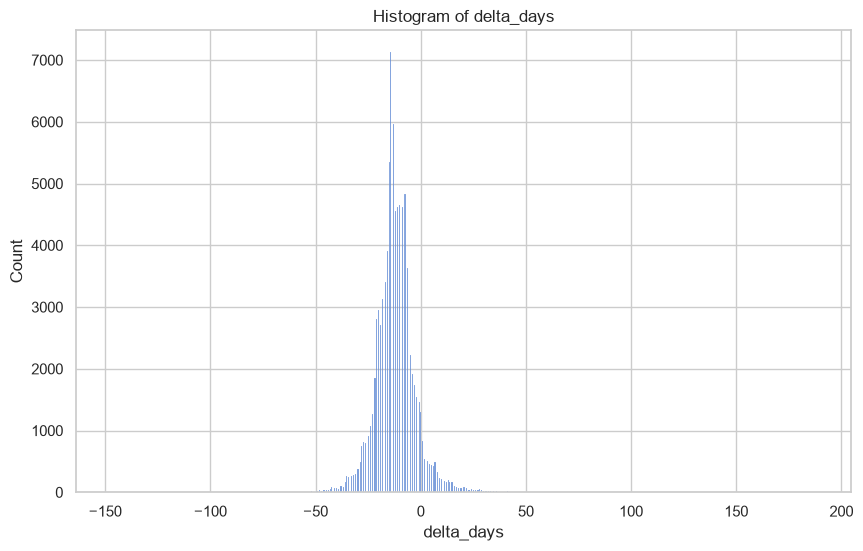

In [56]:
# visualização distribuição da variável-chave em histograma
plt.title('Histogram of delta_days')
sns.histplot(orders_delivered['delta_days'])
plt.show()

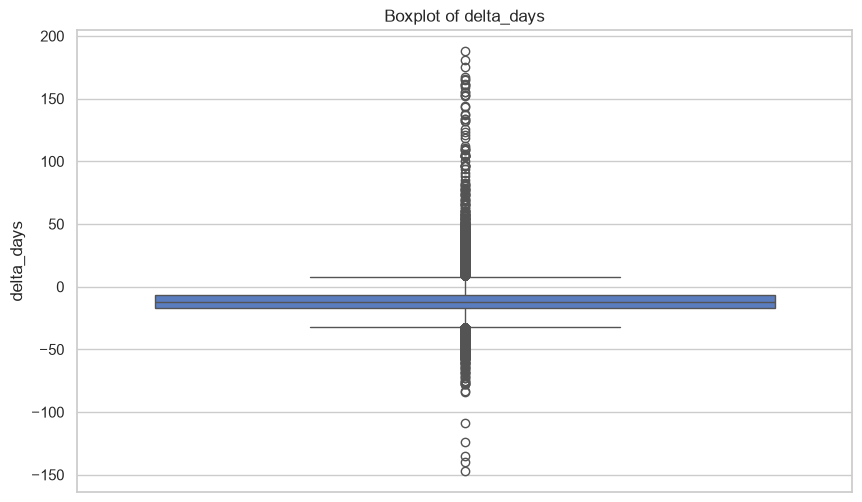

In [57]:
# visualização distribuição da variável-chave em boxplot
plt.title('Boxplot of delta_days')
sns.boxplot(orders_delivered['delta_days'])
plt.show()

A distribuição de `delta_days` revela uma operação estruturalmente antecipada:
- **Mediana: −12 dias** — metade das encomendas chegam 12 dias antes do previsto
- **P75: −7 dias** — 75% das encomendas chegam pelo menos 7 dias antes
- **Amplitude: −147 a +188 dias** — a cauda de atrasos extremos existe, mas é minoritária

A assimetria à direita e a concentração de valores negativos levantam uma questão relevante para as análises seguintes: os prazos estimados são sistematicamente conservadores, ou a operação logística é genuinamente eficiente? Esta questão será retomada na Análise 3 (geografia como factor estrutural).

### Consolidação de dados via SQL

Para responder à Pergunta 1, `delta_days` (calculado em `orders_delivered`) precisa de ser combinado com variáveis que estão noutras tabelas:

| Variável | Tabela de origem |
|---|---|
| `review_score` | `reviews` |
| `category_en` | `order_items` → `products` → `category_translation` |
| `order_value` | `payments` (soma de `payment_value` por pedido) |

Esta consolidação envolve joins entre 5 tabelas — razão pela qual foi feita em SQL (DuckDB), e não em pandas: a lógica relacional fica mais legível eauditável num ficheiro `.sql` separado.

#### Validações antes da query

Antes de escrever a query, foram feitas três verificações para antecipar perdas de linhas e tratar inconsistências:

In [58]:
# descoberta pedidos em orders_delivered que possuem review registrada
print(orders_delivered["order_id"].isin(reviews["order_id"]).value_counts())

order_id
True     95815
False      646
Name: count, dtype: int64


646 pedidos sem correspondência em reviews (serão excluídos pelo INNER JOIN)

In [59]:
# pedidos em orders_delivered que possuem payment registrada
print(orders_delivered["order_id"].isin(payments["order_id"]).value_counts())

order_id
True     96460
False        1
Name: count, dtype: int64


1 pedido sem correspondência em payments (será excluído pelo INNER JOIN)


In [60]:
# descoberta de pedidos com mais de uma review 
print(reviews['order_id'].duplicated().sum())

551


551 pedidos com mais de uma review. Tratamento: mantida a review mais recente por order_id (via ROW_NUMBER no SQL)


#### Execução da query e resultado

In [61]:
# criação função para leitura de arquivos sql externos
def load_query(filename):
    with open(f"../{filename}", encoding="utf-8") as f:
        return f.read() 

In [62]:
# importação dataframe resultante query sql q1
q1 = duckdb.sql(load_query("queries/q1_delay_category_value.sql")).df() 

In [63]:
# visualização df resultado query
q1.head()

,order_id,delta_days,review_score,category_en,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,-8,4,housewares,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,-6,4,perfumery,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,-18,5,auto,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,-13,5,pet_shop,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,-10,5,stationery,28.62


In [64]:
# informações df resultado query
q1.info()

<class 'pandas.DataFrame'>
RangeIndex: 95814 entries, 0 to 95813
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      95814 non-null  str    
 1   delta_days    95814 non-null  int64  
 2   review_score  95814 non-null  int64  
 3   category_en   95814 non-null  str    
 4   order_value   95814 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 3.7 MB


**Resultado:** 95.814 pedidos — sem valores nulos em nenhuma coluna.

Perda de 647 linhas em relação a `orders_delivered` (96.461):
- 646 pedidos sem correspondência em `reviews`
- 1 pedido sem correspondência em `payments`

Pedidos com `category_en = 'unknown'`: categorias nulas em `products` tratadas com `COALESCE` no SQL — mantidos na base para análises que não dependem de categoria.

In [65]:
# descoberta pedidos sem categoria identificada
print((q1["category_en"] == "unknown").sum())

1368


## **Q2 - Ponto de ruptura na Avaliação** 

— A partir de quantos dias de atraso a avaliação do cliente colapsa? A relação é linear ou existe um limiar crítico?

Investigação sobre a relação das variáveis `review_score` e `delta_days` 

### Filtro para pedidos atrasados

In [82]:
# filtro dataframe q1 para apenas pedidos atrasados
q1_delayed = q1[q1['delta_days'] > 0].copy()

In [83]:
# descoberta informações sobre dataframe q1_delayed
q1_delayed.info()

<class 'pandas.DataFrame'>
Index: 6380 entries, 18 to 95805
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      6380 non-null   str    
 1   delta_days    6380 non-null   int64  
 2   review_score  6380 non-null   int64  
 3   category_en   6380 non-null   str    
 4   order_value   6380 non-null   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 299.1 KB


6380 dos 95814 pedidos com review registrada foram entregues com atraso (~7%). 

A minoria numérica não diminui a relevância analítica: são exactamente estes pedidos que geram insatisfação, reclamações e impacto na reputação do vendedor.

### Visualização média de `review_score` por `delta_days`

In [ ]:
# agrupamento média de notas por dia de atraso
average_score_per_day = (
    q1_delayed.groupby('delta_days')['review_score']
    .mean()
    .reset_index()
)

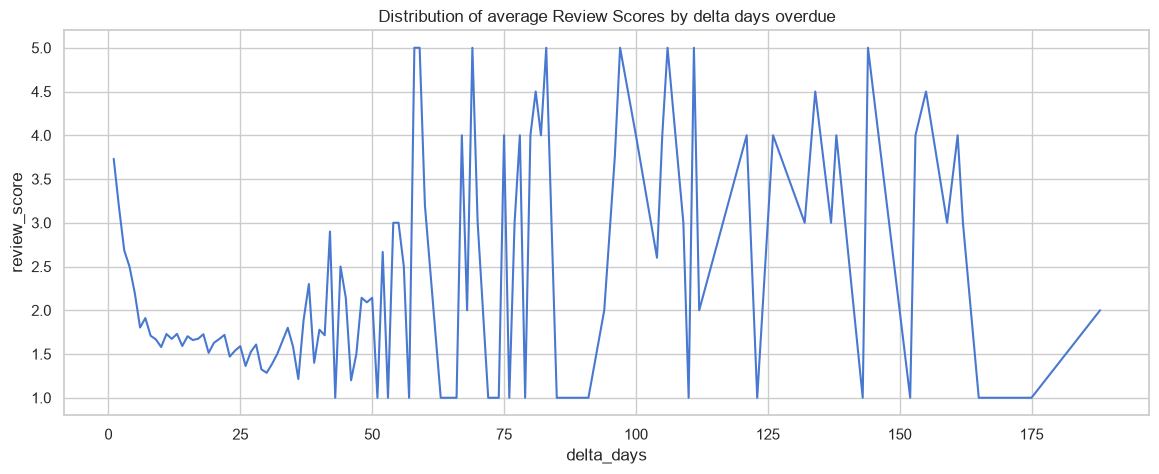

In [ ]:
# visualização distribuição de review scores médios por dia de atraso
plt.figure(figsize=(14, 5))
sns.lineplot(data=average_score_per_day, x='delta_days', y='review_score')
plt.title('Distribution of average Review Scores by delta days overdue (complete vision)')
plt.show()

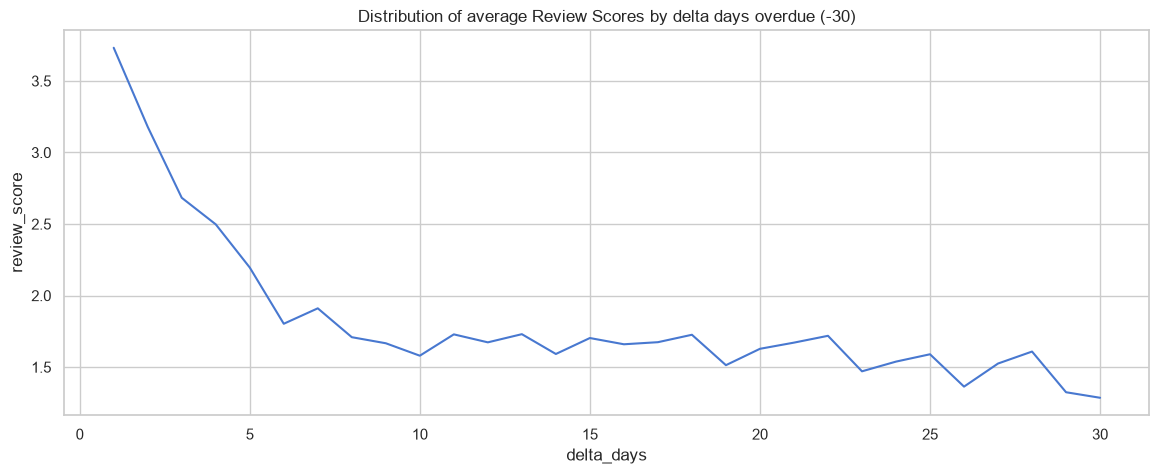

In [ ]:
# visualização aproximada (30 dias) da distribuição de review scores médios por dia de atraso
plt.figure(figsize=(14, 5))
sns.lineplot(data=average_score_per_day[average_score_per_day['delta_days'] < 31], x='delta_days', y='review_score')
plt.title('Distribution of average Review Scores by delta days overdue (first 30 days   )')
plt.show()

A nota média cai de vertiginosamente dentro dos primeiros 6-7 dias de atraso, de ~3.5 para ~2.0. 

É constatada uma mudança de score de ~3.5 para ~1.5 ao fim de 15 dias de atraso.

### Visualização proporção de `review_score` = 1 em faixas `delta_days`

In [92]:
# criação coluna faixas de atraso
q1_delayed['delta_bin'] = pd.cut(
    q1_delayed['delta_days'],
    bins=range(0, q1_delayed['delta_days'].max() + 5, 5),
    right=False
)

In [105]:
# agrupamento de número de pedidos consoante as faixas de atraso
orders_per_bin = q1_delayed.groupby('delta_bin')['order_id'].nunique().reset_index(name='n_orders')
orders_per_bin

,delta_bin,n_orders
0,"[0, 5)",2288
1,"[5, 10)",1860
2,"[10, 15)",898
3,"[15, 20)",485
4,"[20, 25)",312
5,"[25, 30)",195
6,"[30, 35)",86
7,"[35, 40)",62
8,"[40, 45)",43
9,"[45, 50)",36


Com 6.380 pedidos espalhados por ~33 bins, há bins com pouquíssimas observações — especialmente a partir de [60, 65) em diante. 

Isto explica o comportamento errático no gráfico: a partir de ~60 dias, os picos e vales extremos (100% de nota 1, depois 20%, depois 100% outra vez) não reflectem um padrão real — reflectem bins com 2, 3 ou 5 observações, onde 1 cliente insatisfeito move a proporção 20-50 pontos percentuais.

In [93]:
# agrupamento de proporções de reviews score 1 por faixa de atraso 
score1_proportion = (
    q1_delayed.groupby('delta_bin', observed=True)
    .apply(lambda x: (x['review_score'] == 1).sum() / len(x))
    .reset_index(name='score1_proportion')
)

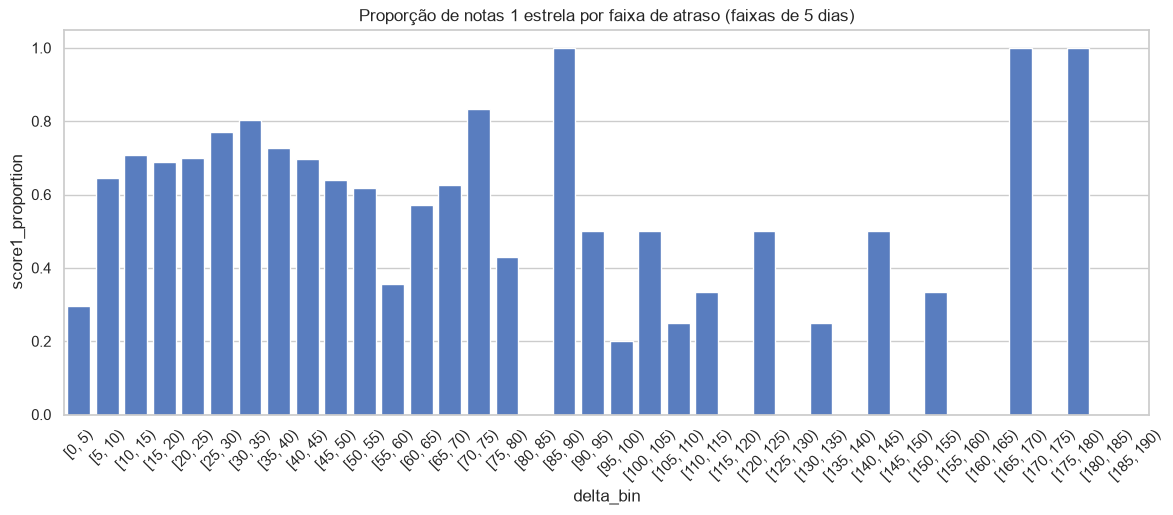

In [101]:
# visualização proporção de reviews score 1 por faixa de atraso
plt.figure(figsize=(14, 5))
sns.barplot(data=score1_proportion, x='delta_bin', y='score1_proportion')
plt.xticks(rotation=45)
plt.title("Proporção de notas 1 estrela por faixa de atraso (faixas de 5 dias)")
plt.show()

A proporção de notas 1 estrela salta de ~30% em `[0,5)` para ~65-70% já em `[5,10)`.

Já em `[25,30)`, a proporção de notas 1 está próxima de 80%. 

Nos bins acima de 60 dias, os valores extremos (0% ou 100%) são ruído de amostra e não devem ser interpretados.

### 2.4 Análise zona crítica (primeiros 30 dias)

In [ ]:
# criação dataframe zona crítica - menores que 30 dias de atraso
critical_zone = q1_delayed[q1_delayed['delta_days'] <= 30].copy()

In [ ]:
# criação agregado com review médio, número de pedidos e proporção de score 1 em avaliações com base em cada delta day dentro da zona critica 
agg_critical_zone = (
    critical_zone.groupby('delta_days')
    .agg(
        avg_review=("review_score", "mean"),
        n_orders=("review_score", "count"),
        score1_proportion=("review_score", lambda x: (x == 1).sum() / len(x))
    )
    .reset_index()
)

agg_critical_zone

,delta_days,review_medio,n_pedidos,score1_proportion
0,1,3.73,820,0.13
1,2,3.18,536,0.27
2,3,2.68,496,0.43
3,4,2.50,436,0.48
4,5,2.20,434,0.55
5,6,1.80,406,0.69
6,7,1.91,471,0.63
7,8,1.71,330,0.69
8,9,1.67,219,0.72
9,10,1.58,207,0.72


A queda ocorre em duas fases:

**Fase 1 — Deterioração progressiva (dias 1 a 5)**
A nota cai de 3.73 para 2.20 e a proporção de nota 1 sobe de 13% para 55%.
O cliente ainda *diferencia* níveis de atraso — um atraso de 1 dia é tratado 
de forma claramente diferente de um atraso de 5 dias.

**Fase 2 — Colapso e estabilização (a partir do dia 6)**
A nota cai abruptamente para ~1.8 e estabiliza entre 1.5–1.7 
indefinidamente. A partir daqui o cliente deixa de diferenciar: 
6 dias ou 30 dias de atraso produzem o mesmo nível de insatisfação.

### **Conclusões** - O limiar está no dia 6.

> **Implicação operacional:** uma transportadora que entrega com 6 dias de atraso está no lado errado do limiar. Reduzir de 8 para 6 dias não resolve o problema — reduzir de 6 para 5 dias pode fazer toda a diferença.


### Classificação dos pedidos: `delay_status`

Com o limiar empiricamente identificado, é possível criar uma variável categórica que será reutilizada nas análises seguintes.

In [ ]:
# criação função de classificação dos atrasos
def classify_delay(delta):
    if delta < 0:
        return "early"
    elif delta == 0:
        return "on_time"
    elif delta <= 5:
        return 'late' # deterioração progressiva — cliente ainda diferencia
    elif delta <= 30:
        return 'late_critical' # colapso — nota estabiliza em ~1.6
    else:
        return 'late_extreme' # volume muito baixo — tratar com cautela

In [122]:
# aplicação função de classificação
q1['delay_status'] = q1['delta_days'].apply(classify_delay)

In [123]:
print(q1['delay_status'].value_counts())

delay_status
early            88154
late_critical     3330
late              2722
on_time           1280
late_extreme       328
Name: count, dtype: int64


**Observação:** `late_extreme` (>30 dias, 328 pedidos, ~0.3%) será incluído em visualizações gerais mas não interpretado em subgrupos — o volume é insuficiente para segmentações por categoria ou estado sem risco elevado de ruído de amostra.

## **Q1- Assimetria do Atraso por Categoria e Valor** 

O mesmo atraso produz o mesmo impacto na avaliação diferente independentemente do contexto? Um atraso de 5 dias em `product_category` de alta expectativa (beleza, moda) vs baixa expectativa (ferramentas, construção) penaliza igual? 

Quais categorias e faixas de valor concentram os maiores atrasos? O atraso distribui-se de forma uniforme ou há padrões específicos?

### Investigação de váriavel - `order_value`

In [ ]:
# características variável order_value
q1['order_value'].describe()

count   95814.00
mean      159.59
std       217.52
min         9.59
25%        61.84
50%       105.28
75%       176.16
max     13664.08
Name: order_value, dtype: float64

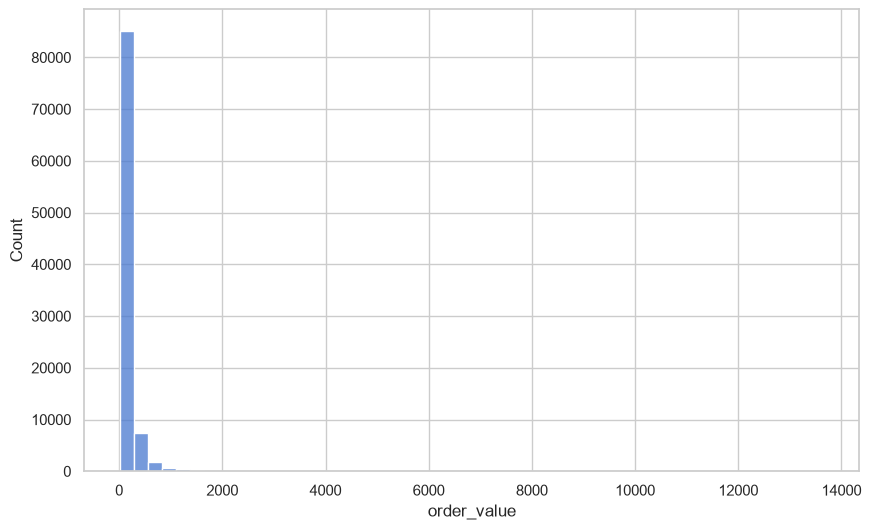

In [ ]:
# visualização da distribuição de order_value 
sns.histplot(q1['order_value'], bins=50)
plt.show()

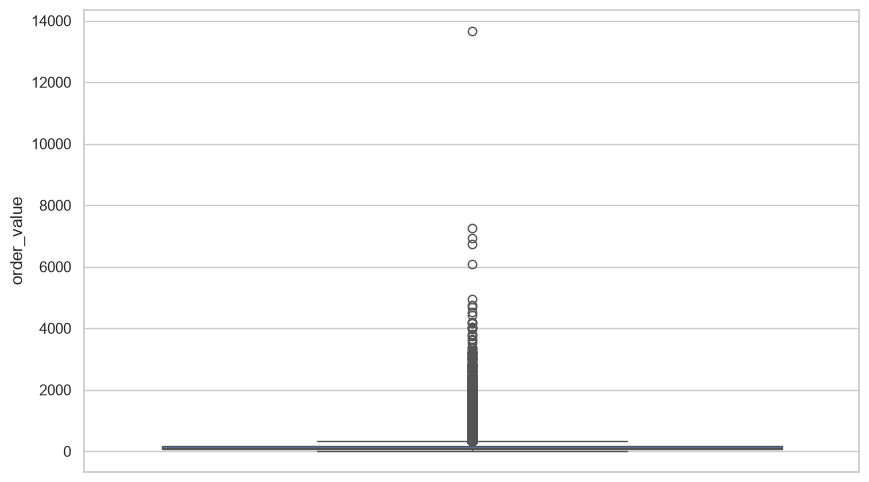

In [130]:
# visualização da distribuição de order_value 
sns.boxplot(q1['order_value'])
plt.show()

O histograma mostra distribuição fortemente assimétrica à direita. A grande maioria dos pedidos concentra-se abaixo de R$500, com uma cauda longa até R$13.664.

### Criação de variável - `value_tier`

In [158]:
# descoberta cauda (P99) da variável `order_values` 
print(q1['order_value'].quantile(0.99))

1048.5361999999986


In [153]:
# criação coluna `value_tier` com base em percentis visualizados
q1['value_tier'] = pd.cut(
    q1['order_value'],
    bins=[0, 61.84, 105.28, 176.16, 1048.54, 13664.08],
    labels=['low', 'medium_low', 'medium', 'high', 'premium'],
    include_lowest=True
)   

In [155]:
# visualização distribuição de valores 
print(q1['value_tier'].value_counts().sort_index())

value_tier
low           23966
medium_low    24034
medium        23863
high          22992
premium         959
Name: count, dtype: int64


`value_tier` definido por quartis de `order_value`, com isolamento do P99 como tier `premium`:

| tier | limite | n pedidos |
|---|---|---|
| low | ≤ R$61.84 | ~24k |
| medium_low | ≤ R$105.28 | ~24k |
| medium | ≤ R$176.16 | ~24k |
| high | ≤ R$1.048.54 | ~23k |
| premium | > R$1.048.54 | ~959 |

Os quatro tiers base têm volumes equilibrados por construção (quartis), o que garante que comparações entre grupos não são distorcidas por diferenças de volume. O tier `premium` tem volume reduzido mas significado analítico distinto — pedidos acima de R$1.048 representam 1% do total e podem ter perfil de insatisfação diferente dos restantes.

### Volume de atrasos por categoria

In [ ]:
# criação agregado de número de pedidos atrasados e review médio para cada categoria de produto
volume_category = (
    q1[q1['delay_status'].isin(['late', 'late_critical', 'late_extreme'])]
    .groupby('category_en')
    .agg(
        n_delayeds=('order_id', 'count'),
        average_review=('review_score', 'mean')
    )
    .sort_values('n_delayeds', ascending=False)
    .reset_index()
)

In [ ]:
# visualização resultados do agregado
volume_category.head(20)

,category_en,n_delayeds,average_review
0,bed_bath_table,666,2.23
1,health_beauty,633,2.35
2,sports_leisure,486,2.17
3,furniture_decor,438,2.33
4,computers_accessories,407,2.27
5,watches_gifts,395,2.20
6,housewares,300,2.26
7,telephony,287,2.43
8,auto,273,2.31
9,toys,232,2.13


A variação de `average_review` entre as 20 categorias com mais atrasos é pequena — vai de 2.07 (baby) a 2.43 (telephony), uma amplitude de apenas 0.36 pontos percentuais.

### Investigação `category_en`, `delay_status` e `review_score` 

In [163]:
# criação agregado de número de pedidos atrasados, review médio para cada categoria de produto e delay_status
volume_category_status = (
    q1[q1['delay_status'].isin(['late', 'late_critical'])]
    .groupby(['category_en', 'delay_status'])
    .agg(
        n_delayeds=('order_id', 'count'),
        average_review=('review_score', 'mean'),
        score1_proportion=('review_score', lambda x: (x == 1).sum() / len(x))
    )
    .reset_index()
    .sort_values(['delay_status', 'n_delayeds'], ascending=[True, False])
)

In [170]:
volume_category_status.head(10)

,category_en,delay_status,n_delayeds,average_review,score1_proportion
13,bed_bath_table,late,275,2.93,0.37
76,health_beauty,late,273,3.21,0.29
112,sports_leisure,late,192,2.83,0.42
68,furniture_decor,late,186,3.02,0.30
26,computers_accessories,late,178,3.12,0.29
123,watches_gifts,late,172,2.87,0.34
117,telephony,late,137,3.12,0.27
87,housewares,late,129,2.98,0.33
9,auto,late,118,3.12,0.33
74,garden_tools,late,98,2.96,0.37


In [ ]:
# top 10 categorias por volume
top10 = volume_category.head(10)['category_en'].tolist()

# 
print(
    volume_category_status[
        volume_category_status['category_en'].isin(top10)
    ].to_string()
)

               category_en   delay_status  n_delayeds  average_review  score1_proportion
13          bed_bath_table           late         275            2.93               0.37
76           health_beauty           late         273            3.21               0.29
112         sports_leisure           late         192            2.83               0.42
68         furniture_decor           late         186            3.02               0.30
26   computers_accessories           late         178            3.12               0.29
123          watches_gifts           late         172            2.87               0.34
117              telephony           late         137            3.12               0.27
87              housewares           late         129            2.98               0.33
9                     auto           late         118            3.12               0.33
119                   toys           late          84            2.62               0.46
14          bed_bath_

### Conclusão parcial: a assimetria existe — mas numa janela estreita

Dois padrões emergem com clareza:

**`late_critical` (≥6 dias): colapso uniforme** 
Todas as categorias convergem para review médio ~1.6–1.8 e proporção de nota 1 ~66–75%. A categoria deixa de ser um factor diferenciador — o cliente já está insatisfeito independentemente do que comprou.

**`late` (1–5 dias): janela de diferenciação**
É aqui que a categoria importa. `toys` (46% de nota 1) e `sports_leisure` (42%) são significativamente mais penalizados do que `health_beauty` (29%) ou `telephony` (27%) para o mesmo intervalo de atraso.

Uma hipótese plausível: categorias associadas a ocasiões com data específica (brinquedos para aniversários, equipamento desportivo para eventos) têm menor tolerância a qualquer atraso — mas esta hipótese 
requereria validação com dados adicionais sobre sazonalidade ou motivação de compra, que não estão disponíveis neste dataset.

> **Síntese:** O atraso não é simétrico — mas a janela de diferenciação entre categorias é estreita: apenas nos primeiros 5 dias. Acima de 6 dias, > o contexto da compra deixa de importar.

### Visualização